In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/clean/sales_data.csv')

print(f"Shape: {df.shape}")
print(f"Teams: {sorted(df['team'].unique())}")
print(f"Days: {df['day'].nunique()}")
df.head()

Shape: (224, 9)
Teams: ['Ben Traill', 'Beth Ogilvie', 'Jack Inglis', 'Joel Robertson', 'Paula Wilson', 'Reece Wright', 'Ryan Watt', 'Scott Brodie']
Days: 28


,team,calls,broadband,mobile,tv,regrades,hh_orders,hh_value,day
0,Ben Traill,205.0,21.0,42.0,7.0,12.0,32.0,1051.13,1
1,Beth Ogilvie,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1
2,Jack Inglis,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1
3,Joel Robertson,34.0,0.0,0.0,0.0,0.0,0.0,0.00,1
4,Paula Wilson,58.0,6.0,9.0,1.0,0.0,8.0,313.44,1


In [ ]:
# Conversion rate = broadband sales / calls 
df['bb_conversion'] = df['broadband'] / df['calls'].replace(0, np.nan)

# Total new sales (broadband, mobile, TV only - new products)
df['total_new_sales'] = df['broadband'] + df['mobile'] + df['tv']

# Total transactions including regrades - used for products per HH
df['total_transactions'] = df['broadband'] + df['mobile'] + df['tv'] + df['regrades']

# BB conversion rate 
df['bb_conversion'] = df['broadband'] / df['calls'].replace(0, np.nan)

# Products per household including regrades
df['products_per_hh'] = df['total_transactions'] / df['hh_orders'].replace(0, np.nan)

# Value per call
df['value_per_call'] = df['hh_value'] / df['calls'].replace(0, np.nan)

print("Core metrics added:")
print(df[['team', 'day', 'bb_conversion', 'products_per_hh', 'value_per_call']].head(10))   

Core metrics added:
             team  day  bb_conversion  products_per_hh  value_per_call
0      Ben Traill    1       0.102439         2.562500        5.127463
1    Beth Ogilvie    1            NaN              NaN             NaN
2     Jack Inglis    1            NaN              NaN             NaN
3  Joel Robertson    1       0.000000              NaN        0.000000
4    Paula Wilson    1       0.103448         2.000000        5.404138
5    Reece Wright    1       0.069767         4.333333        1.488140
6       Ryan Watt    1       0.200000         1.545455       10.612000
7    Scott Brodie    1       0.196429         1.850000       13.571071
8      Ben Traill    2       0.178082         2.500000        6.121096
9    Beth Ogilvie    2       0.153846         1.344828        8.236538


In [3]:
# TARGETS 
TARGETS = {
    'hh_value':    28.50,   # £28.50
    'bb_conv':     0.1800,  # 18.00%
    'mob_conv':    0.1420,  # 14.20%
    'tv_conv':     0.0580,  #  5.80%
    'combined_conv': 0.3220 # 32.20% BB + Mobile combined
}

# Daily conversion rates per row
df['mob_conversion']      = df['mobile']   / df['calls'].replace(0, np.nan)
df['tv_conversion']       = df['tv']       / df['calls'].replace(0, np.nan)
df['combined_conversion'] = (df['broadband'] + df['mobile']) / df['calls'].replace(0, np.nan)
df['avg_hh_value']        = df['hh_value'] / df['hh_orders'].replace(0, np.nan)

# Daily variance vs target (positive = above target, negative = below)
df['bb_vs_target']       = df['bb_conversion']       - TARGETS['bb_conv']
df['mob_vs_target']      = df['mob_conversion']       - TARGETS['mob_conv']
df['tv_vs_target']       = df['tv_conversion']        - TARGETS['tv_conv']
df['combined_vs_target'] = df['combined_conversion']  - TARGETS['combined_conv']
df['hh_value_vs_target'] = df['avg_hh_value']         - TARGETS['hh_value']

print("Targets loaded and daily variances calculated.")
print(f"\nTarget summary:")
for k, v in TARGETS.items():
    print(f"  {k}: {v}")

Targets loaded and daily variances calculated.

Target summary:
  hh_value: 28.5
  bb_conv: 0.18
  mob_conv: 0.142
  tv_conv: 0.058
  combined_conv: 0.322


In [5]:
# Aggregate everything to monthly level per team
monthly = df.groupby('team').agg(
    total_calls=('calls', 'sum'),
    total_broadband=('broadband', 'sum'),
    total_mobile=('mobile', 'sum'),
    total_tv=('tv', 'sum'),
    total_regrades=('regrades', 'sum'),
    total_hh_orders=('hh_orders', 'sum'),
    total_hh_value=('hh_value', 'sum'),
    total_new_sales=('total_new_sales', 'sum'),
    total_transactions=('total_transactions', 'sum'),
    days_worked=('day', 'count')
).reset_index()

# Recalculate metrics at monthly level
# Note: calls are only reliable at monthly aggregate level
monthly['bb_conversion'] = (monthly['total_broadband'] / monthly['total_calls'] * 100).round(2)
monthly['products_per_hh'] = (monthly['total_new_sales'] / monthly['total_hh_orders']).round(2)
monthly['value_per_call'] = (monthly['total_hh_value'] / monthly['total_calls']).round(2)
monthly['avg_daily_sales'] = (monthly['total_new_sales'] / monthly['days_worked']).round(2)

# Monthly conversion rates (reliable at this aggregate level)
monthly['bb_conv']       = monthly['total_broadband'] / monthly['total_calls']
monthly['mob_conv']      = monthly['total_mobile']    / monthly['total_calls']
monthly['tv_conv']       = monthly['total_tv']        / monthly['total_calls']
monthly['combined_conv'] = (monthly['total_broadband'] + monthly['total_mobile']) / monthly['total_calls']
monthly['avg_hh_value']  = monthly['total_hh_value']  / monthly['total_hh_orders']

# Monthly variance vs target
monthly['bb_vs_target']       = (monthly['bb_conv']       - TARGETS['bb_conv']).round(4)
monthly['mob_vs_target']      = (monthly['mob_conv']       - TARGETS['mob_conv']).round(4)
monthly['tv_vs_target']       = (monthly['tv_conv']        - TARGETS['tv_conv']).round(4)
monthly['combined_vs_target'] = (monthly['combined_conv']  - TARGETS['combined_conv']).round(4)
monthly['hh_value_vs_target'] = (monthly['avg_hh_value']   - TARGETS['hh_value']).round(2)

# Round display columns
monthly['bb_conv_pct']      = (monthly['bb_conv'] * 100).round(2)
monthly['mob_conv_pct']     = (monthly['mob_conv'] * 100).round(2)
monthly['tv_conv_pct']      = (monthly['tv_conv'] * 100).round(2)
monthly['combined_conv_pct']= (monthly['combined_conv'] * 100).round(2)

print("Monthly summary with target variance:")
monthly[['team', 'bb_conv_pct', 'mob_conv_pct', 'tv_conv_pct', 
         'combined_conv_pct', 'avg_hh_value',
         'bb_vs_target', 'mob_vs_target', 'tv_vs_target', 
         'combined_vs_target', 'hh_value_vs_target']].sort_values('combined_vs_target', ascending=False)

Monthly summary with target variance:


,team,bb_conv_pct,mob_conv_pct,tv_conv_pct,combined_conv_pct,avg_hh_value,bb_vs_target,mob_vs_target,tv_vs_target,combined_vs_target,hh_value_vs_target
6,Ryan Watt,18.22,17.15,7.26,35.36,32.924401,0.0022,0.0295,0.0146,0.0316,4.42
0,Ben Traill,18.35,15.70,5.78,34.05,37.618699,0.0035,0.0150,-0.0002,0.0185,9.12
1,Beth Ogilvie,16.55,15.98,6.63,32.53,31.337117,-0.0145,0.0178,0.0083,0.0033,2.84
5,Reece Wright,16.86,14.95,6.04,31.81,47.873815,-0.0114,0.0075,0.0024,-0.0039,19.37
7,Scott Brodie,15.18,16.60,4.54,31.78,30.624279,-0.0282,0.0240,-0.0126,-0.0042,2.12
4,Paula Wilson,14.92,15.01,4.61,29.93,35.057163,-0.0308,0.0081,-0.0119,-0.0227,6.56
2,Jack Inglis,15.68,12.64,4.56,28.32,28.889217,-0.0232,-0.0156,-0.0124,-0.0388,0.39
3,Joel Robertson,16.26,11.95,3.45,28.20,29.089458,-0.0174,-0.0225,-0.0235,-0.0400,0.59


In [6]:
print("=== TEAM RANKINGS ===\n")

metrics = {
    'Total HH Value (£)': ('total_hh_value', False),
    'BB Conversion (%)': ('bb_conversion', False),
    'Products per HH': ('products_per_hh', False),
    'Total Broadband': ('total_broadband', False),
    'Total Mobile': ('total_mobile', False),
    'Total TV': ('total_tv', False),
}

for label, (col, asc) in metrics.items():
    ranked = monthly.sort_values(col, ascending=asc)[['team', col]].reset_index(drop=True)
    ranked.index += 1
    print(f"--- {label} ---")
    print(ranked.to_string())
    print()

=== TEAM RANKINGS ===

--- Total HH Value (£) ---
             team  total_hh_value
1       Ryan Watt        28578.38
2    Paula Wilson        25451.50
3     Jack Inglis        16235.74
4    Beth Ogilvie        15323.85
5      Ben Traill        14746.53
6    Scott Brodie        13382.81
7  Joel Robertson        12886.63
8    Reece Wright        11920.58

--- BB Conversion (%) ---
             team  bb_conversion
1      Ben Traill          18.35
2       Ryan Watt          18.22
3    Reece Wright          16.86
4    Beth Ogilvie          16.55
5  Joel Robertson          16.26
6     Jack Inglis          15.68
7    Scott Brodie          15.18
8    Paula Wilson          14.92

--- Products per HH ---
             team  products_per_hh
1    Reece Wright             3.65
2      Ben Traill             2.30
3    Paula Wilson             1.55
4       Ryan Watt             1.33
5    Scott Brodie             1.28
6    Beth Ogilvie             1.27
7  Joel Robertson             1.16
8     Jack Ingl

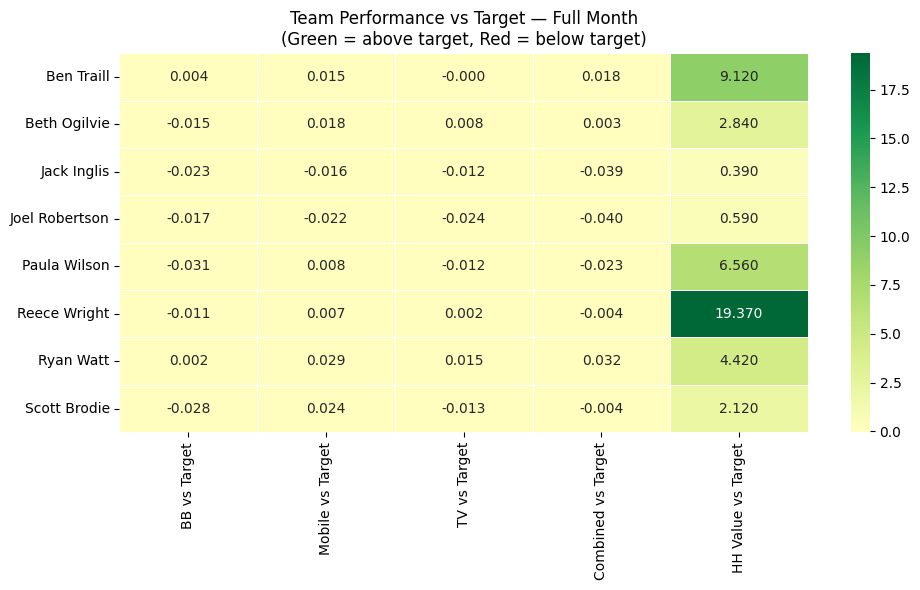

In [7]:
# Heatmap showing each team's variance vs target across all metrics
# Green = above target, Red = below target

variance_data = monthly.set_index('team')[[
    'bb_vs_target', 'mob_vs_target', 'tv_vs_target', 
    'combined_vs_target', 'hh_value_vs_target'
]].copy()

# Rename for display
variance_data.columns = ['BB vs Target', 'Mobile vs Target', 'TV vs Target', 
                          'Combined vs Target', 'HH Value vs Target']

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    variance_data,
    cmap='RdYlGn',      # Red = below, Yellow = at, Green = above
    center=0,           # Centre the colour scale at zero (= on target)
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Team Performance vs Target — Full Month\n(Green = above target, Red = below target)')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../data/clean/target_variance_heatmap.png', dpi=150)
plt.show()

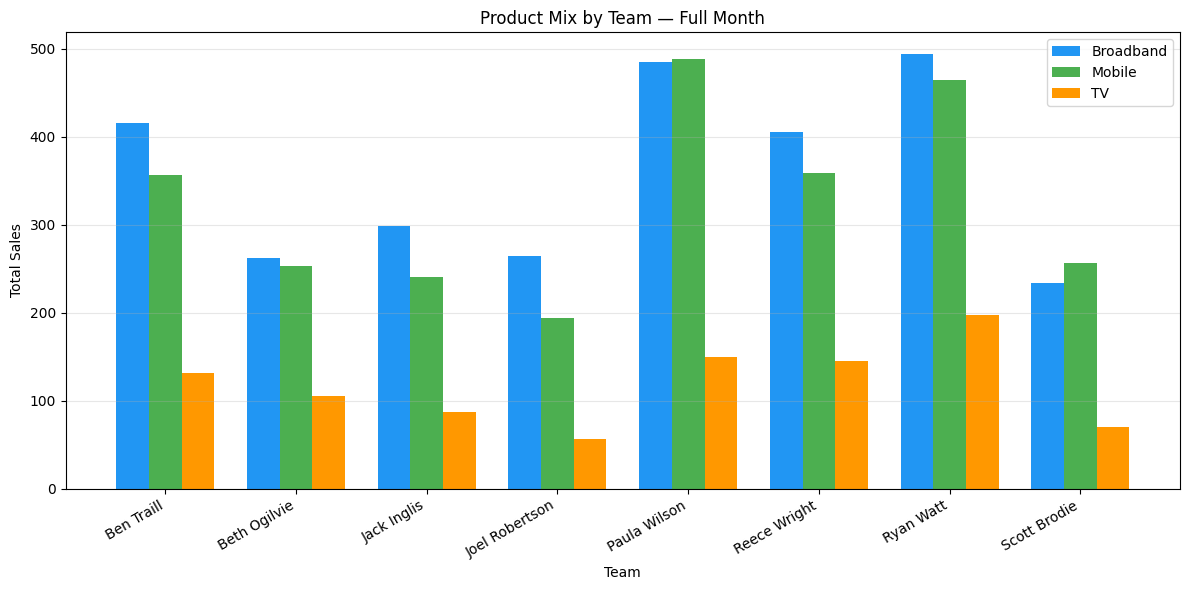

Chart saved.


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

teams = monthly['team']
x = np.arange(len(teams))
width = 0.25

bars1 = ax.bar(x - width, monthly['total_broadband'], width, label='Broadband', color='#2196F3')
bars2 = ax.bar(x, monthly['total_mobile'], width, label='Mobile', color='#4CAF50')
bars3 = ax.bar(x + width, monthly['total_tv'], width, label='TV', color='#FF9800')

ax.set_xlabel('Team')
ax.set_ylabel('Total Sales')
ax.set_title('Product Mix by Team — Full Month')
ax.set_xticks(x)
ax.set_xticklabels(teams, rotation=30, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/clean/product_mix.png', dpi=150)
plt.show()
print("Chart saved.")

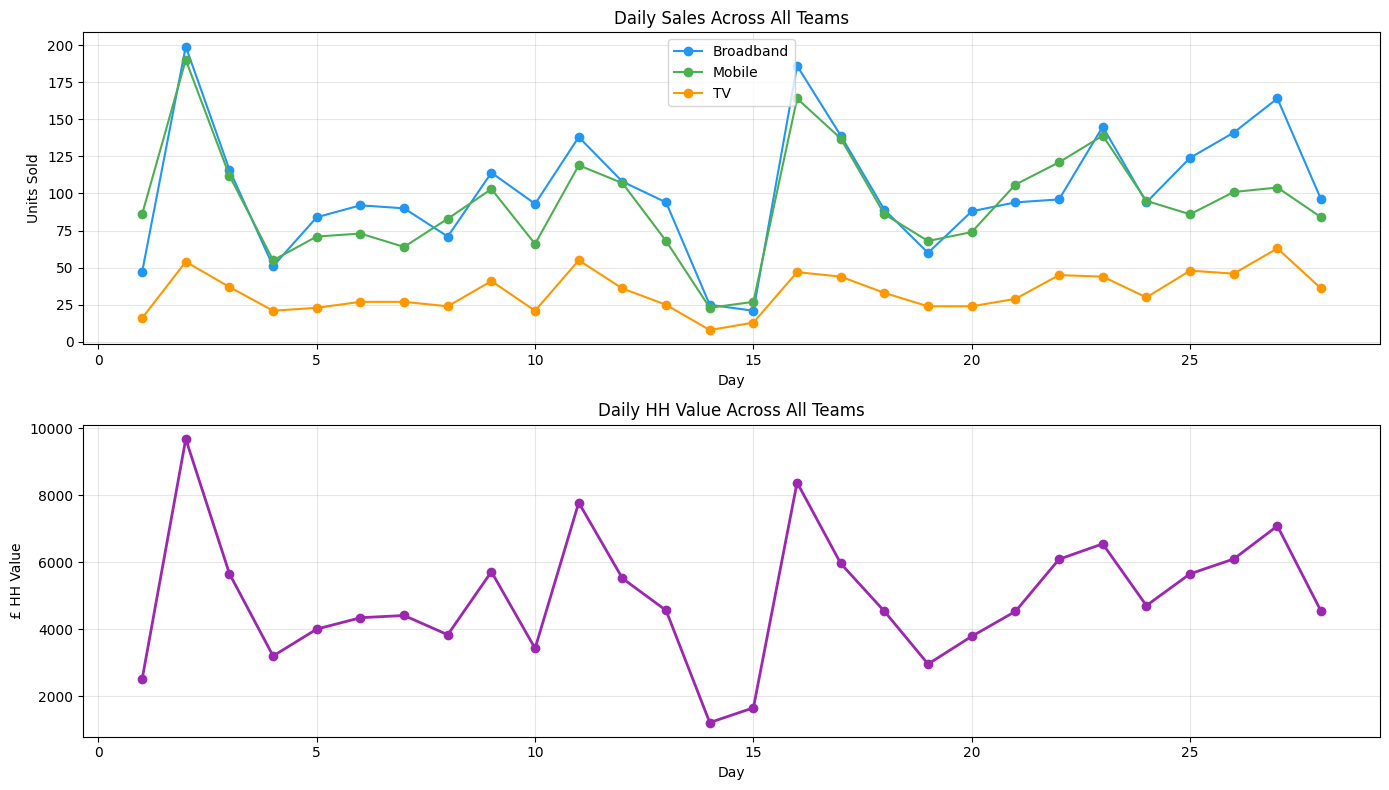

In [10]:
# Daily totals across all teams
daily_totals = df.groupby('day').agg(
    broadband=('broadband', 'sum'),
    mobile=('mobile', 'sum'),
    tv=('tv', 'sum'),
    hh_value=('hh_value', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Sales trend
axes[0].plot(daily_totals['day'], daily_totals['broadband'], marker='o', label='Broadband', color='#2196F3')
axes[0].plot(daily_totals['day'], daily_totals['mobile'], marker='o', label='Mobile', color='#4CAF50')
axes[0].plot(daily_totals['day'], daily_totals['tv'], marker='o', label='TV', color='#FF9800')
axes[0].set_title('Daily Sales Across All Teams')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Units Sold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# HH Value trend
axes[1].plot(daily_totals['day'], daily_totals['hh_value'], marker='o', color='#9C27B0', linewidth=2)
axes[1].set_title('Daily HH Value Across All Teams')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('£ HH Value')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/clean/daily_trends.png', dpi=150)
plt.show()

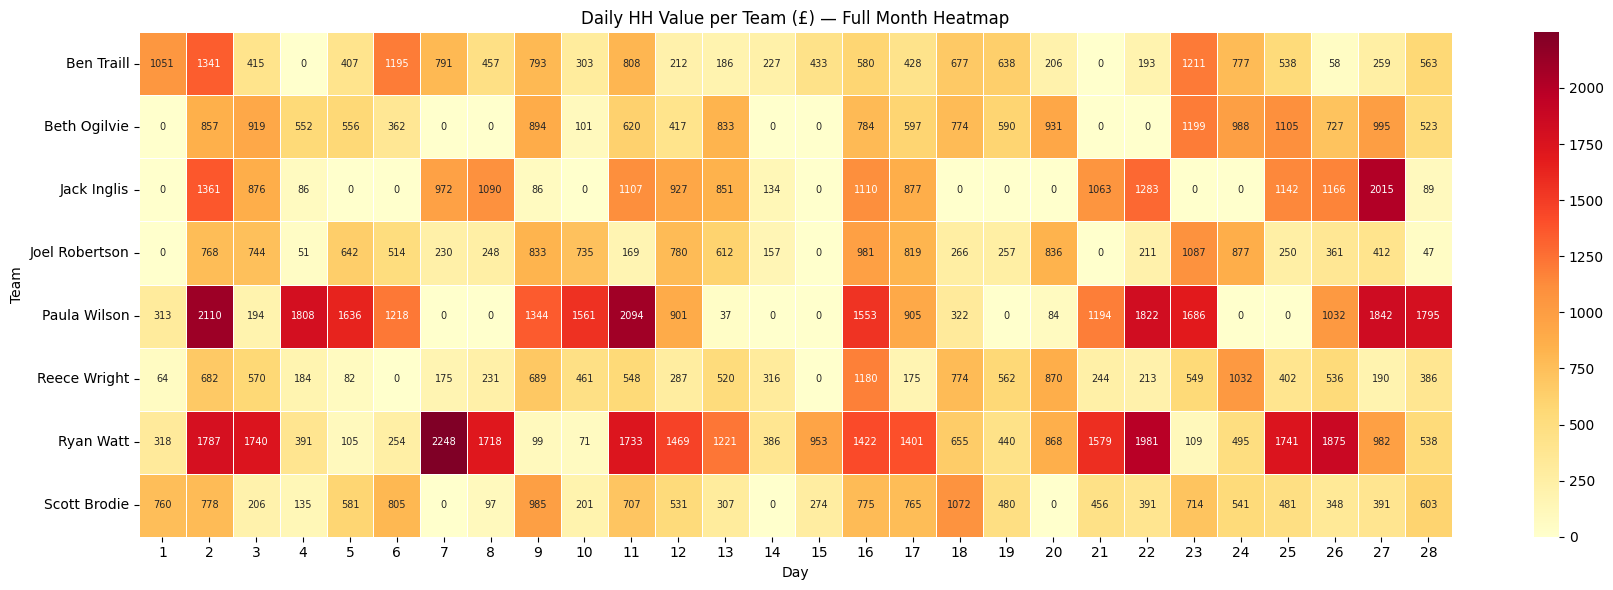

In [11]:
# Pivot table — teams as rows, days as columns, HH value as values
heatmap_data = df.pivot_table(
    index='team',
    columns='day',
    values='hh_value',
    aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    fmt='.0f',
    annot=True,
    annot_kws={'size': 7}
)
ax.set_title('Daily HH Value per Team (£) — Full Month Heatmap')
ax.set_xlabel('Day')
ax.set_ylabel('Team')

plt.tight_layout()
plt.savefig('../data/clean/heatmap.png', dpi=150)
plt.show()

## Key Findings — Team Rankings

**Volume leaders:** Ryan Watt and Paula Wilson dominate raw sales numbers 
across all three products and lead on total HH value for the month.

**Efficiency leader:** Reece Wright's products-per-HH of 3.65 is nearly 
3x the centre average, suggesting a bundling-focused approach that 
maximises value per household interaction rather than call volume.

**Conversion leader:** Ben Traill is the only team to exceed the 18% BB 
conversion target, though this does not translate to top HH value — 
suggesting room to improve bundling and upsell on converted calls.

**Consistent underperformance:** Joel Robertson ranks last or near-last 
across every metric for the month. This pattern warrants closer 
operational attention.

**Key insight:** Raw volume and conversion efficiency tell different stories. 
A balanced performance framework should reward both dimensions rather 
than ranking teams on a single metric.